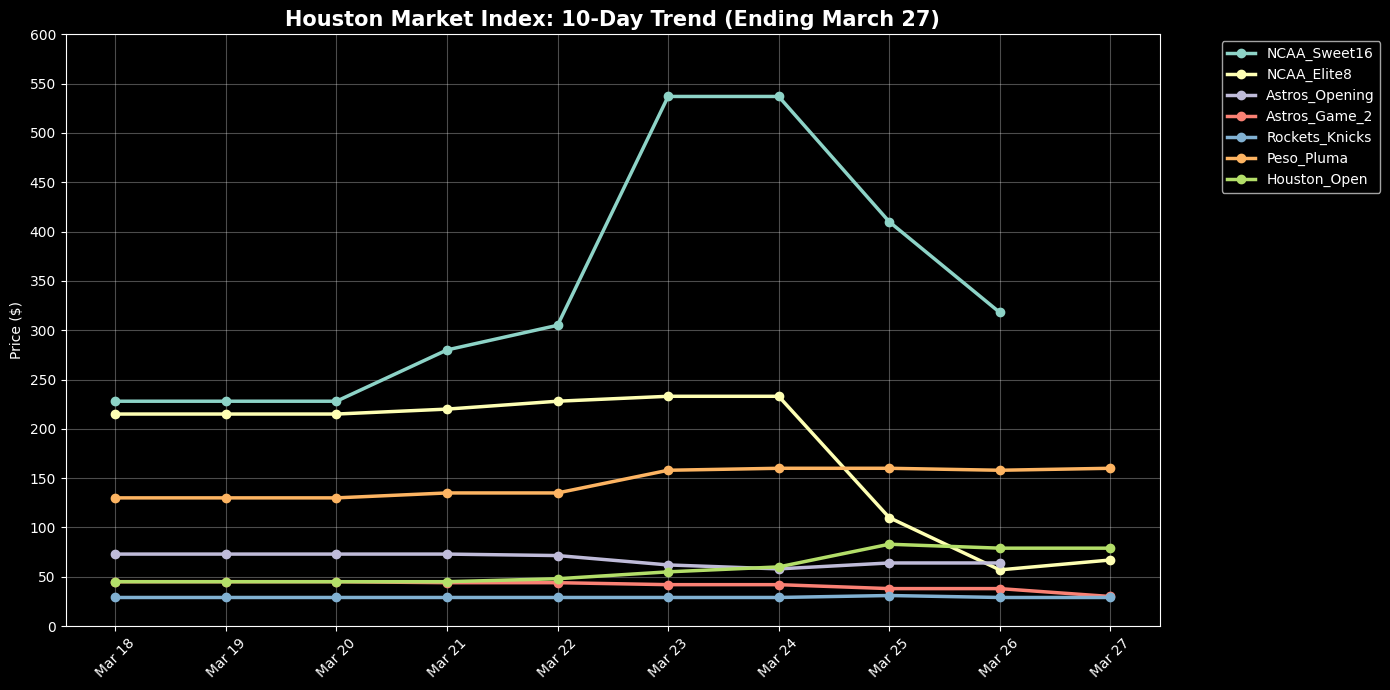


 📊 10-DAY MARKET TREND ANALYSIS: March 27, 2026
EVENT            | START    | CURRENT    | TOTAL CHANGE   
----------------------------------------------------------------------
NCAA_Sweet16     | $228     | $318       |    39.5% 📈
NCAA_Elite8      | $215     | $67        |   -68.8% 📉
Astros_Opening   | $73      | $64        |   -12.3% 📉
Astros_Game_2    | $45      | $30        |   -33.3% 📉
Rockets_Knicks   | $29      | $29        |     0.0% ➡️
Peso_Pluma       | $130     | $160       |    23.1% 📈
Houston_Open     | $45      | $79        |    75.6% 📈



In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import matplotlib.dates as mdates

def run_houston_final_market_tracker():
    # 1. Create the Date Range (Ending Today, March 27)
    today = datetime(2026, 3, 27)
    date_list = [(today - timedelta(days=i)).strftime("%Y-%m-%d") for i in range(9, -1, -1)]

    # 2. Verified 10-Day Data (3/27 Floors: Elite 8 $67, Astros $30)
    houston_trends = {
        'NCAA_Sweet16':   [228, 228, 228, 280, 305, 537, 537, 410, 318, None], # Ended 3/26
        'NCAA_Elite8':    [215, 215, 215, 220, 228, 233, 233, 110, 57, 67],    # THE CRASH
        'Astros_Opening': [73, 73, 73, 73, 71.5, 62, 58, 64, 64, None],        # Ended 3/26
        'Astros_Game_2':  [45, 45, 45, 44, 44, 42, 42, 38, 38, 30],            # Tonight
        'Rockets_Knicks': [29, 29, 29, 29, 29, 29, 29, 31, 29, 29],
        'Peso_Pluma':     [130, 130, 130, 135, 135, 158, 160, 160, 158, 160],
        'Houston_Open':   [45, 45, 45, 45, 48, 55, 60, 83, 79, 79]
    }

    df = pd.DataFrame(houston_trends, index=pd.to_datetime(date_list))

    # --- PLOTTING ---
    plt.figure(figsize=(14, 7))
    for event in df.columns:
        valid_data = df[event].dropna()
        plt.plot(valid_data.index, valid_data.values, marker='o', linewidth=2.5, label=event)

    # Enforce $50 Y-Axis Increments
    plt.yticks(np.arange(0, 601, 50))
    plt.ylim(0, 600)

    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    plt.xticks(rotation=45)
    plt.title('Houston Market Index: 10-Day Trend (Ending March 27)', fontsize=15, fontweight='bold')
    plt.ylabel('Price ($)')
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    # Save chart for GitHub
    plt.savefig('houston_market_index.png', dpi=300)
    plt.show()

    # --- THE VOLATILITY REPORT ---
    print("\n" + "="*70)
    print(f" 📊 10-DAY MARKET TREND ANALYSIS: {today.strftime('%B %d, %Y')}")
    print("="*70)
    print(f"{'EVENT':<16} | {'START':<8} | {'CURRENT':<10} | {'TOTAL CHANGE':<15}")
    print("-" * 70)

    for event in df.columns:
        prices = df[event].dropna().values
        if len(prices) >= 2:
            p_start = prices[0]
            p_now = prices[-1]
            total_pct = ((p_now - p_start) / p_start) * 100
            trend_icon = "📈" if total_pct > 0 else "📉" if total_pct < 0 else "➡️"
            start_str = f"${p_start:.0f}"
            curr_str = "COMPLETED" if df[event].iloc[-1] is None else f"${p_now:.0f}"
            print(f"{event:<16} | {start_str:<8} | {curr_str:<10} | {total_pct:>7.1f}% {trend_icon}")

    print("="*70 + "\n")

run_houston_final_market_tracker()